# Wstęp
Zadanie 6 stanowi wprowadzenie w tematykę *data augmentation*. Ze względu na złożonośc modeli głębokich, zwykle wymagają one bardzo dużych zbiorów danych do dobrego wyuczenia. Jednym ze sposobów na skalowanie ilości dostępnych danych są metody tzw. augmentacji - przekształcenia na danych które mamy, aby utworzyć nowe przykłady o znanych etykietach. Pod koniec zadania wprowadzona jest również koncepcja *skip connections*, będących istotnym elementem współczesnych architektur konwolucyjnych i nie tylko.

#Cel ćwiczenia

Celem ćwiczenia jest zapoznanie się z

*    koncepcją augmentacji danych
*    implementacją metod augmentacji danych obrazowych w torch.transforms
*    koncepcją augmentacji niezależnej od dziedziny
*    modelami sieci głębokich ze skip connections

#Augmentacja danych obrazowych

W pierwszej kolejności zapoznajmy się z funkcjonalnością augmentacji danych obrazowych. W pytorch funkcjonalność ta realizowana jest przez transformacje wykonywane na obrazach przez `torchvision.transforms`.

Transformacje które typowo wykorzystuje się w augmentacji to standardowe przekształcenia afiniczne obrazu - rotacje, dobicia, skalowanie. Oczywiście, pownniśmy dobierać transformacje z takich, po których rzeczywiście oczekujemy inwariancji - przekształcony obraz będziemy podawać do sieci z tą samą etykietą. Przykładowo, na zbiorze odręcznie pisanych cyfr MNIST ograniczymy zakres obrotów czy wykorzystanie odbicia w osi poziomej, jako że niechcemy pomylić 5 z 2 czy 6 z 9.

Zapoznaj się z dokumentacją transforms tutaj:

https://pytorch.org/vision/stable/transforms.html

Kod poniżej wczytuje CIFAR 10 i pokazuje wyniki przykładowej augmentacji - losowej rotacji o kąt -30 do 30 stopni.

In [1]:
import torchvision

/home/kociecki/repos/studia/deep-neural-network-pwr/.venv/lib/python3.12/site-packages/torchvision/datasets/cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


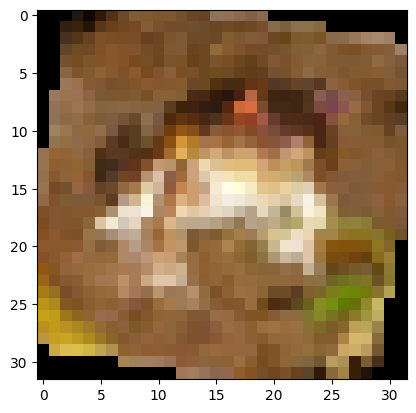

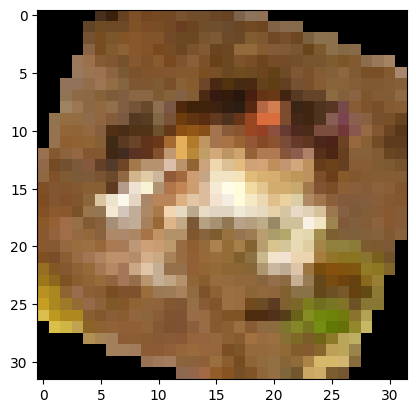

In [2]:
import torch
import torchvision.transforms as transforms
from matplotlib import pyplot as plt


transform = transforms.Compose([
    transforms.RandomRotation(30),
    transforms.ToTensor()
])

train_ds = torchvision.datasets.CIFAR10("cifar_root", transform=transform, download=True)
img, label = train_ds[0]

plt.imshow(img.permute(1,2,0))
plt.show()

img, label = train_ds[0]

plt.imshow(img.permute(1,2,0))
plt.show()

Widzimy tutaj kolejny potencjalny problem z augmentacjami: ze względu na konieczność utrzymania stałego kształtu wejścia, augmentacje mogą wprowadzać artefakty takie jak czarne fragmenty na krawędziach obrazu czy aliasing wynikający z niskiej rozdzielczości.

Poniżej kod pomocniczy z laboratorium 3, można zastąpić go własną implementacją pętli uczącej uwzględniającej ulepszenia wykonane na laboratoriach 4 i 5. W zadaniach poniżej wystarczy porównać końcowy wynik uczenia, nie jest wymagane wyrysowywanie pełnych krzywych w tensorboard niemniej mogą one pomóc w analizie otrzymanych wyników.

In [ ]:
import torchvision
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from typing import Tuple
from tqdm import tqdm
import mlflow
import mlflow.pytorch

mlflow.set_tracking_uri("sqlite:///mlflow.db")

transform = torchvision.transforms.ToTensor()

train_ds = torchvision.datasets.CIFAR10("cifar_root", transform=transform, download=True)
test_ds = torchvision.datasets.CIFAR10("cifar_root", transform=transform, train=False, download=True)

train_dl = DataLoader(train_ds, batch_size=32, shuffle=True, pin_memory=True)
test_dl = DataLoader(test_ds, batch_size=32, pin_memory=True)

def count_correct(y_pred: torch.Tensor, y_true: torch.Tensor) -> torch.Tensor:
    preds = torch.argmax(y_pred, dim=1)
    return (preds == y_true).float().sum()

def validate(
    model: nn.Module, loss_fn: torch.nn.CrossEntropyLoss, dataloader: DataLoader
) -> Tuple[torch.Tensor, torch.Tensor]:
    loss = 0
    correct = 0
    all_samples = 0
    for X_batch, y_batch in dataloader:
        y_pred = model(X_batch)
        all_samples += len(y_pred)
        loss += loss_fn(y_pred, y_batch).sum()
        correct += count_correct(y_pred, y_batch)
    return loss / all_samples, correct / all_samples

def fit(
    model: nn.Module, optimiser: optim.Optimizer,
    loss_fn: torch.nn.CrossEntropyLoss, train_dl: DataLoader,
    val_dl: DataLoader, epochs: int,
    print_metrics: bool = True,
    run_name: str = "Default_Run",
    log_params: dict = None
):
    with mlflow.start_run(run_name=run_name):
        
        mlflow.log_param("epochs", epochs)
        if log_params:
            mlflow.log_params(log_params)

        for epoch in range(epochs):
            model.train()
            for X_batch, y_batch in tqdm(train_dl, desc=f"Epoka {epoch}/{epochs-1}"):
                y_pred = model(X_batch)
                loss = loss_fn(y_pred, y_batch)

                loss.backward()
                optimiser.step()
                optimiser.zero_grad()

            if print_metrics:
                model.eval()
                with torch.no_grad():
                    train_loss, train_acc = validate(model, loss_fn, train_dl)
                    val_loss, val_acc = validate(model, loss_fn, val_dl)
                    
                    print(
                        f"Epoch {epoch}: "
                        f"train loss = {train_loss:.3f} (acc: {train_acc:.3f}), "
                        f"val loss = {val_loss:.3f} (acc: {val_acc:.3f})"
                    )

                    mlflow.log_metric("train_loss", train_loss.item(), step=epoch)
                    mlflow.log_metric("train_acc", train_acc.item(), step=epoch)
                    mlflow.log_metric("val_loss", val_loss.item(), step=epoch)
                    mlflow.log_metric("val_acc", val_acc.item(), step=epoch)
                    
        mlflow.pytorch.log_model(model, f"model_{run_name}")


/home/kociecki/repos/studia/deep-neural-network-pwr/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/home/kociecki/repos/studia/deep-neural-network-pwr/.venv/lib/python3.12/site-packages/torchvision/datasets/cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


# Zadanie 1

Wykorzystując klasę ThreeLayerCNN z `channels=32`, spróbuj dobrać augmentacje danych tak aby poprawić wyniki względem jej braku na zbiorze CIFAR10.

In [4]:
class ThreeLayerCNN(torch.nn.Module):
  def __init__(self, channels: int, labels: int):
    super().__init__()
    self.model = torch.nn.Sequential()
    self.model.add_module("in_conv",
                          torch.nn.Conv2d(3, channels, 1))
    self.model.add_module("relu_1", torch.nn.ReLU())
    self.model.add_module("conv_1",
                          torch.nn.Conv2d(channels, channels, 3, padding=1))
    self.model.add_module("relu_2", torch.nn.ReLU())
    self.model.add_module("max_pool_1", torch.nn.MaxPool2d(2))
    self.model.add_module("conv_2",
                          torch.nn.Conv2d(channels, channels, 3, padding=1))
    self.model.add_module("relu_3", torch.nn.ReLU())
    self.model.add_module("max_pool_2", torch.nn.MaxPool2d(2))
    self.model.add_module("flatten", torch.nn.Flatten())
    self.model.add_module("linear", torch.nn.Linear(channels * 8 * 8, labels)) #uzupełnij

  def forward(self, x):
    return self.model(x)

Zaprogramuj eksperyment tak, aby w pętli sprawdzać kolejne potencjalne wersje potoku przetwarzania (różniące się tutaj tylko augmentacją), a na końcu wybrać najlepszą - tak aby możliwe było powtórzenie całego eksperymentu uzasadniającego wybór! Transformacja z augmentacją ma być wywoływana tylko na danych treningowych.

Spróbuj znaleźć również przykład augmentacji pogarszającej wynik w stosunku do bazowego otrzymanego bez augmentacji. Wykorzystaj uczenie na 50 epok i optymalizator Adam z domyślnymi parametrami, bez regularyzacji.

In [ ]:
import torchvision.transforms as transforms

transformations = {
    "baseline": transforms.Compose([
        transforms.ToTensor()
    ]),

    "horizontal_flip_crop": transforms.Compose([
        transforms.RandomHorizontalFlip(p=0.5),
        transforms.RandomCrop(32, padding=4),
        transforms.ToTensor()
    ]),

    "color_jitter": transforms.Compose([
        transforms.RandomHorizontalFlip(p=0.5),
        transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.05),
        transforms.ToTensor()
    ]),

    "rotation_15deg": transforms.Compose([
        transforms.RandomHorizontalFlip(p=0.5),
        transforms.RandomRotation(degrees=15),
        transforms.ToTensor()
    ]),

    "heavy_composite": transforms.Compose([
        transforms.RandomHorizontalFlip(p=0.5),
        transforms.RandomCrop(32, padding=4),
        transforms.RandomRotation(degrees=15),
        transforms.ColorJitter(brightness=0.2, contrast=0.2),
        transforms.ToTensor(),
        transforms.RandomErasing(p=0.2, scale=(0.02, 0.1)) 
    ]),

    "vertical_flip_only": transforms.Compose([
        transforms.RandomVerticalFlip(p=1.0),
        transforms.ToTensor()
    ]),

    "gaussian_blur": transforms.Compose([
        transforms.GaussianBlur(kernel_size=11, sigma=(2.0, 3.0)),
        transforms.ToTensor()
    ])
}

epochs = 50

for name, train_transform in transformations.items():
    print(f"Starting: {name}")

    train_ds_aug = torchvision.datasets.CIFAR10("cifar_root", transform=train_transform, train=True, download=True)
    train_dl_aug = DataLoader(train_ds_aug, batch_size=32, shuffle=True, pin_memory=True)
    
    model = ThreeLayerCNN(channels=32, labels=10)
    loss_fn = nn.CrossEntropyLoss()
    optimiser = optim.Adam(model.parameters())
    
    fit(
        model=model,
        optimiser=optimiser,
        loss_fn=loss_fn,
        train_dl=train_dl_aug, 
        val_dl=test_dl,       
        epochs=epochs,
        print_metrics=True,
        run_name=f"Augmentacja_{name}",
        log_params={"augmentation_type": name, "optimizer": "Adam"}
    )

Starting: baseline


Epoka 0/49:   0%|          | 0/1563 [00:00<?, ?it/s]/home/kociecki/repos/studia/deep-neural-network-pwr/.venv/lib/python3.12/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
Epoka 0/49: 100%|██████████| 1563/1563 [01:42<00:00, 15.29it/s]


Epoch 0: train loss = 0.039 (acc: 0.567), val loss = 0.040 (acc: 0.549)


Epoka 1/49: 100%|██████████| 1563/1563 [01:19<00:00, 19.72it/s]


Epoch 1: train loss = 0.033 (acc: 0.640), val loss = 0.034 (acc: 0.614)


Epoka 2/49: 100%|██████████| 1563/1563 [01:12<00:00, 21.42it/s]


Epoch 2: train loss = 0.029 (acc: 0.675), val loss = 0.032 (acc: 0.641)


Epoka 3/49: 100%|██████████| 1563/1563 [01:20<00:00, 19.43it/s]


# Mixup - augmentacja ogólna

Augmentacja daje nam spore możliwości w sytuacji, gdy w dziedzinie danych jesteśmy w stanie wskazać przekształcenia na kóre nasz model powinien być **inwariantny** - dla obrazków niewielkie skalowanie czy przesunięcie nie powinno zmieniać wyniku, zaś dla tekstu, podstawianie synonimów może spełniać podobną rolę. Ale w augmentacji danych możliwe jest też podejście niezależne od typu danych, wynikające z obserwacji dotyczących dynamiki uczenia sieci głębokich w ogóle. Ciekawym przykładem jest tu augmentacja Mixup:

https://arxiv.org/abs/1710.09412

Zasada działania mixup jest niezwykle prosta - generujemy nowe przykłady jako **kombinacje liniowe** tych istniejących w zbiorze danych i oczekujemy, że ich etykiety również będą kombinacjami liniowymi etykiet. Innymi słowy, dla pary przykładów z etykietami: $(x_1, y_1)$, $(x_2, y_2)$, możemy wygenerować przykład $(x', y')$:

$x' = \lambda x_1 + (1-\lambda) x_2$

$y' = \lambda y_1 + (1-\lambda) y_2$

Wartość $\lambda$ jest tutaj losowana z rozkładu Beta - animacja podana na https://en.wikipedia.org/wiki/Beta_distribution#Definitions dobrze obrazuje, jak wygląda ten rozkład dla różnych parametryzacji.

# Zadanie 2

Zmodyfikuj funkcję fit tak, aby uczyć zgodnie z podanym wyżej sformułowaniem augmentacji Mixup. (Pamiętaj, że model musi przyjmować etykiety w postaci kombinacji dwóch klas. Będzie to wymagało modyfikacji funkcji kosztu! )

In [ ]:
def fit(
    model: nn.Module, optimiser: optim.Optimizer,
    loss_fn: torch.nn.CrossEntropyLoss, train_dl: DataLoader,
    val_dl: DataLoader, epochs: int,
    print_metrics: str = True
):
  for epoch in range(epochs):
      for X_batch, y_batch in tqdm(train_dl):

          # zmodyfikuj implementację pętli uczącej

          loss.backward()
          optimiser.step()
          optimiser.zero_grad()

      if print_metrics:
          model.eval()
          with torch.no_grad():
              train_loss, train_acc = validate(
                  model=model, loss_fn=loss_fn, dataloader=train_dl
              )
              val_loss, val_acc = validate(
                  model=model, loss_fn=loss_fn, dataloader=val_dl
              )
              print(
                  f"Epoch {epoch}: "
                  f"train loss = {train_loss:.3f} (acc: {train_acc:.3f}), "
                  f"validation loss = {val_loss:.3f} (acc: {val_acc:.3f})"
              )

Sprawdź, czy uzyskuje ona przewagę nad modelem trenowanym bez augmentacji.



In [ ]:
# przetestuj wyniki z wykorzystaniem zmodyfikowanego fit()

# Skrótowe połączenia

W kontekście sieci konwolucyjnych warto zpoznać się jeszcze z jedną istotną koncepcją: połączenia omijające warstwy, poprzez konkatenacje ich wyniku z wynikami dalszych warstw lub dodawanie ich wyniku do wyjścia dalszej warstwy (w drugim przypadku mówimy też o połączeniach *rezydualnych*). Połączenia takie są potrzebne szczególnie przy trenowaniu sieci bardzo głębokich, zawierających dziesiątki czy nawet ponad 100 warstw, czego nie będziemy w stanie realistycznie zrealizować w czasie naszych laboratoriów. Niemniej warto zapoznać się zarówno z samą ideą, jak i ich implementacją, jako że przy pracy z architekturami *state of the art* będziemy często natykać się na takie konstrukcje.

W konstrukcji sieci z połączeniamy pomijającymi warstwy i połączeniami rezydualnymi często będziemy spotykać się z powtarzalnymi *blokami* obejmującymi kilka warstw - dobrą praktyką implementacyjną jest wydzielanie takich bloków jako osobnych podklas `torch.nn.Module`. Warto też z góry zwrócić uwagę, że znane nam już `torch.nn.Sequential` nie uwzględnia połączeń innych niż sekwencyjne - czyli połączenia rezydualne i omijanie warstw nie wchodzi w grę, chyba że w obrębie wydzielonego bloku.

# Zadanie 3

Uzupełnij kod klasy SkipBlock tak, aby implementowała blok o zadanej strukturze.

Struktura SkipBlock:


*  zadana liczba `n` warstw konwolucyjnch, `channels x channels` kanałów, filtr 3x3, padding 1
*  aktywacja ReLU po każdej warstwie
*  pooling 2x pod koniec całego bloku
*  parametr `skip`: jeśli jest ustawiony na `true`, do wyjścia po ReLU należy **dodać** pierwotne wejście do warstwy konwolucyjnej, jeśli `false` mamy zwyczajną sekwencję warstw konwolucyjnych z aktywacjami

(Dla `skip=false` i `n=1` struktura sieci powinna odpowiadać ThreeLayerCNN powyżej.)

In [ ]:
class SkipBlock(torch.nn.Module)
  def __init__(self, in_channels: int, out_channels: int):
    # zaimplementuj konstruktor

  def forward(self,x):
    #zaimplementuj forward



class SkipBlockCNN(torch.nn.Module):
  def __init__(self, channels: int, labels: int, n:int,  skip: bool):
    super().__init__()
    self.model = torch.nn.Sequential()
    self.model.add_module("in_conv", ___ ) #uzupełnij
    self.model.add_module("skip_1", SkipBlock(skip=skip, n, channels))
    self.model.add_module("skip_2", SkipBlock(skip=skip, n, channels))
    self.model.add_module("flatten", torch.nn.Flatten())
    self.model.add_module("linear", __ ) #uzupełnij

  def forward(self, x):
    return self.model(x)

 Wyucz sieć SkipBlockCNN i porównaj jej wyniki z wcześniej uzykanymi. Porównaj wyniki w zależności od tego, czy włączone są skip connections.

In [ ]:
model = SkipBlockCNN(channels=32, labels=10, n=3, skip=True)

# wyucz sieć i porównaj wyniki